✅ rim vents generated: n_vents=138  (spacing=50.0 m)
   lava threshold=0.5 m, simplify=5.0 m
✅ mask quicklook → energy_cone_mu_0.25_rimvents/lava_mask.png


/var/folders/xd/msh5srmj40702mpq6nhmmpjw0000gn/T/ipykernel_49452/3507038911.py:231: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_union.to_file(shp_union)
/Users/tomo/Documents/Numerical/EnergyCone/.venvec/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'rim_spacing_m' to 'rim_spacin'
  ogr_write(


✅ union Shapefile → energy_cone_mu_0.25_rimvents/merged_mu_0.25_union.shp


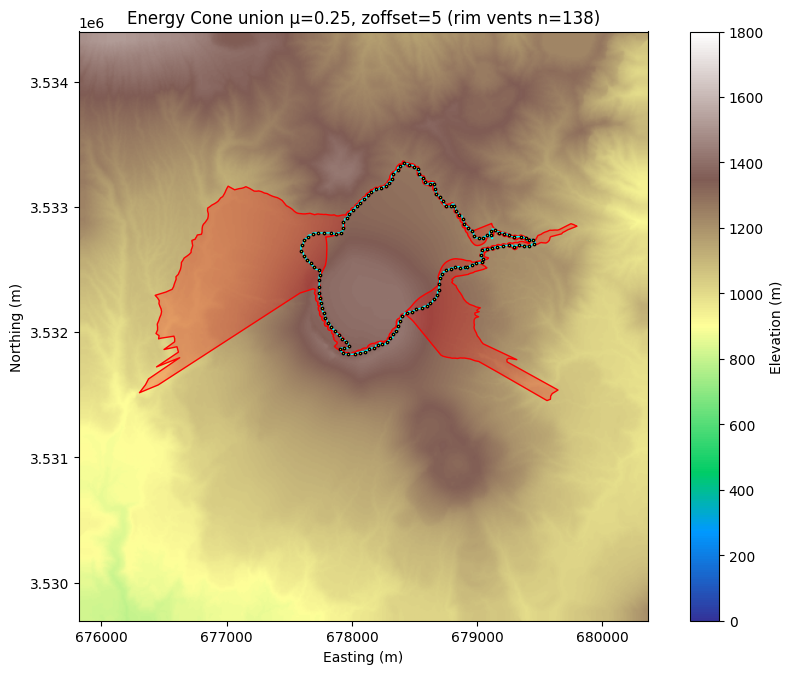

✅ union PNG → energy_cone_mu_0.25_rimvents/merged_mu_0.25_union.png


In [3]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon, LineString
from shapely.ops import unary_union
from rasterio.warp import reproject, Resampling
from rasterio.features import shapes
from shapely.geometry import shape as shp_shape
import os

# =========================================================
# 入力
# =========================================================
dem_with_lava_tif = "../demShinmoeRL2025N.tif"          # 溶岩あり（現状のDEM）
dem_no_lava_tif   = "../demShinmoe2025_nolava.tif"      # 溶岩なし（ユーザー指定）

mu = 0.25
zoffset = 5
crs_epsg = "EPSG:6689"

az_step_deg = 1.0

# vents生成パラメータ
rim_spacing_m = 50.0          # リム上のvent間隔（重ければ100-200へ）
thickness_threshold_m = 0.5   # 差分がこれ以上を溶岩とみなす（0.2, 0.5, 1.0で調整）
simplify_m = 5.0              # 外周ギザギザ抑制（0で無効）
min_area_m2 = 0.0             # 小領域除去（ノイズ多ければ 1e4 など）

# 出力
root_dir = f"energy_cone_mu_{mu:.2f}_rimvents"
os.makedirs(root_dir, exist_ok=True)

# =========================================================
# 1) 参照格子に合わせて2枚のDEMを揃えて読む（必要ならリサンプル）
# =========================================================
def _read_as_ref_grid(src_path, ref_profile):
    with rasterio.open(src_path) as src:
        arr = src.read(1).astype(np.float32)
        sp = src.profile

        same_grid = (
            sp["crs"] == ref_profile["crs"] and
            sp["transform"] == ref_profile["transform"] and
            sp["width"] == ref_profile["width"] and
            sp["height"] == ref_profile["height"]
        )
        if same_grid:
            return arr, sp

        out = np.full((ref_profile["height"], ref_profile["width"]), np.nan, dtype=np.float32)
        reproject(
            source=arr,
            destination=out,
            src_transform=sp["transform"],
            src_crs=sp["crs"],
            dst_transform=ref_profile["transform"],
            dst_crs=ref_profile["crs"],
            resampling=Resampling.bilinear,
            src_nodata=sp.get("nodata", None),
            dst_nodata=np.nan
        )
        sp2 = ref_profile.copy()
        sp2["dtype"] = "float32"
        sp2["nodata"] = np.nan
        return out, sp2

with rasterio.open(dem_with_lava_tif) as srcL:
    dem = srcL.read(1).astype(np.float32)
    transform = srcL.transform
    bounds = srcL.bounds
    dem_crs = srcL.crs
    dem_profile = srcL.profile
    invA = ~transform

extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)
rows, cols = dem.shape
px = (abs(transform.a) + abs(transform.e)) * 0.5
dr = px

# 溶岩なしを溶岩あり（dem_with_lava）格子へ合わせて読む
dem_nolava, _ = _read_as_ref_grid(dem_no_lava_tif, dem_profile)

# =========================================================
# 2) 差分で溶岩域マスク → ポリゴン → 外周リム → vents
# =========================================================
diff = dem - dem_nolava
mask = np.isfinite(diff) & (diff >= thickness_threshold_m)

geoms = []
for geom, val in shapes(mask.astype(np.uint8), mask=mask, transform=transform):
    if val != 1:
        continue
    poly = shp_shape(geom)
    if (min_area_m2 > 0) and (poly.area < min_area_m2):
        continue
    geoms.append(poly)

if not geoms:
    raise RuntimeError("溶岩域が抽出できませんでした。thickness_threshold_m を下げる等で調整してください。")

lava_poly = unary_union(geoms)
if lava_poly.geom_type == "MultiPolygon":
    # とりあえず最大面積だけ（外周だけ欲しいので）
    lava_poly = max(list(lava_poly.geoms), key=lambda p: p.area)

if simplify_m and simplify_m > 0:
    lava_poly = lava_poly.simplify(simplify_m, preserve_topology=True)

# CRSを指定（DEMと同じ）→EPSG:6689へ
gdf_lava = gpd.GeoDataFrame(geometry=[lava_poly], crs=dem_crs).to_crs(crs_epsg)
lava_poly = gdf_lava.geometry.iloc[0]

rim = LineString(lava_poly.exterior.coords)
L = rim.length
n = max(3, int(np.floor(L / rim_spacing_m)))
dists = np.linspace(0, L, n, endpoint=False)
vents = [(float(rim.interpolate(d).x), float(rim.interpolate(d).y)) for d in dists]

print(f"✅ rim vents generated: n_vents={len(vents)}  (spacing={rim_spacing_m} m)")
print(f"   lava threshold={thickness_threshold_m} m, simplify={simplify_m} m")

# （任意）確認用：マスクとリムventsのチェック図を保存
fig, ax = plt.subplots(figsize=(7,7))
ax.imshow(mask, origin="upper")
ax.set_title("Lava mask (diff >= threshold)")
plt.tight_layout()
mask_png = os.path.join(root_dir, "lava_mask.png")
plt.savefig(mask_png, dpi=200)
plt.close(fig)
print("✅ mask quicklook →", mask_png)

# =========================================================
# 3) エナジーコーン（merge-only）
#    ここから下は、以前のmerge-onlyと同じ
# =========================================================
def sample_dem_bilinear(x, y):
    col_f, row_f = invA * (x, y)
    if (col_f < 0) or (row_f < 0) or (col_f > cols - 1) or (row_f > rows - 1):
        return np.nan
    c0 = int(np.floor(col_f)); r0 = int(np.floor(row_f))
    c1 = min(c0 + 1, cols - 1); r1 = min(r0 + 1, rows - 1)
    dc = col_f - c0; drf = row_f - r0
    z00 = dem[r0, c0]; z10 = dem[r0, c1]
    z01 = dem[r1, c0]; z11 = dem[r1, c1]
    z0_ = z00 * (1 - dc) + z10 * dc
    z1_ = z01 * (1 - dc) + z11 * dc
    return float(z0_ * (1 - drf) + z1_ * drf)

def raycast_boundary_for_vent(x0, y0, mu, zoffset, az_step_deg=1.0, dr=10.0):
    col0, row0 = invA * (x0, y0)
    col0 = int(np.clip(np.floor(col0), 0, cols-1))
    row0 = int(np.clip(np.floor(row0), 0, rows-1))
    z0 = float(dem[row0, col0])

    corners = [(extent[0], extent[2]), (extent[0], extent[3]),
               (extent[1], extent[2]), (extent[1], extent[3])]
    r_max_bound = max(np.hypot(x0 - cx, y0 - cy) for (cx, cy) in corners) + 2 * dr

    az_list = np.arange(0.0, 360.0, az_step_deg)
    stop_xy = []

    for az in az_list:
        rad = np.deg2rad(az); dx = np.cos(rad); dy = np.sin(rad)
        r = 0.0
        zt_prev = sample_dem_bilinear(x0, y0)
        zc_prev = z0 + zoffset
        hit = None

        while r <= r_max_bound:
            r += dr
            x = x0 + r * dx
            y = y0 + r * dy

            zt = sample_dem_bilinear(x, y)
            if np.isnan(zt):
                break

            zc = z0 + zoffset - mu * r

            if zt >= zc:
                r1 = r - dr
                f0 = zc_prev - zt_prev
                f1 = zc - zt
                alpha = 0.0
                if (f0 - f1) != 0:
                    alpha = np.clip(f0 / (f0 - f1), 0.0, 1.0)
                r_star = r1 + alpha * dr
                x_star = x0 + r_star * dx
                y_star = y0 + r_star * dy
                hit = (x_star, y_star)
                break

            zc_prev, zt_prev = zc, zt

        if hit is None:
            hit = (x, y)

        stop_xy.append(hit)

    poly = None
    pts = np.asarray(stop_xy)
    if len(pts) >= 3:
        poly = Polygon(pts)
        if not poly.is_valid:
            poly = poly.buffer(0)

    return poly

# ventsが多いと激重なので、まず間引きオプション（必要なら有効化）
# vents = vents[::2]

polys = []
for (x0, y0) in vents:
    poly = raycast_boundary_for_vent(x0, y0, mu, zoffset, az_step_deg=az_step_deg, dr=dr)
    if (poly is not None) and (not poly.is_empty):
        polys.append(poly)

if not polys:
    raise RuntimeError("有効ポリゴンが作れませんでした（μ/zoffset/az_step_deg/drを確認）")

union_geom = unary_union(polys)
gdf_union = gpd.GeoDataFrame(
    {"mu":[mu], "zoffset":[zoffset], "n_vents":[len(vents)], "az_step":[az_step_deg], "dr_m":[dr],
     "rim_spacing_m":[rim_spacing_m], "thresh_m":[thickness_threshold_m], "simplify_m":[simplify_m]},
    geometry=[union_geom],
    crs=crs_epsg
)

shp_union = os.path.join(root_dir, f"merged_mu_{mu:.2f}_union.shp")
gdf_union.to_file(shp_union)
print("✅ union Shapefile →", shp_union)

# union PNG
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(dem, cmap="terrain", extent=extent, origin="upper", vmin=0, vmax=1800)
plt.colorbar(im, ax=ax, label="Elevation (m)")
ax.set_title(f"Energy Cone union μ={mu:.2f}, zoffset={zoffset} (rim vents n={len(vents)})")

# 溶岩外周（確認用、薄く）
gdf_lava.boundary.plot(ax=ax, color="cyan", linewidth=1.0, zorder=6)

# union
gdf_union.plot(ax=ax, facecolor=(1,0,0,0.25), edgecolor="red", linewidth=1.0, zorder=5)

# vents点（かなり多いので点は小さく）
ax.scatter([x for x,y in vents], [y for x,y in vents], c="yellow", edgecolors="black", s=3, zorder=11)

ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3])
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout()

out_png = os.path.join(root_dir, f"merged_mu_{mu:.2f}_union.png")
plt.savefig(out_png, dpi=300)
plt.show()
print("✅ union PNG →", out_png)
